In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("../")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
import jax
from housemaze import utils
from housemaze.human_dyna import multitask_env as maze
from housemaze.human_dyna import mazes
from analysis import housemaze_user_data
from experiment_utils import SuccessTrackingAutoResetWrapper
from nicewebrl import dataframe

dummy_env_params = housemaze_user_data.make_env_params(mazes.big_practice_maze)
dummy_rng = jax.random.PRNGKey(42)
task_runner = maze.TaskRunner(task_objects=housemaze_user_data.task_objects)
base_env = maze.HouseMaze(
  task_runner=task_runner,
  num_categories=200,
)
web_env = SuccessTrackingAutoResetWrapper(base_env)
example_web_timestep = web_env.reset(dummy_rng, dummy_env_params)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


In [4]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
searches = {
  # 'Paths': f'{data_dir}/user_data/*exps*/*v1*paths*.json',
  # "Start": f"{data_dir}/user_data/*exps*/*v3*start*.json",
  # 'Plan (Tell)': f'{data_dir}/user_data/*exps*/*exp5*v1*r1-t0-plan*.json',
  # "Plan (Don't Tell)": f'{data_dir}/user_data/*exps*/*v1*r0-t0-plan*.json',
  # 'Shortcut': f'{data_dir}/user_data/*exps*/*v3*shortcut*.json',
}

valid_files = housemaze_user_data.get_valid_files(searches)

Start: 25/25 valid files


In [6]:
# TESTING
# df, data = housemaze_user_data.make_episode_data(
#     file=valid_files[0], example_timestep=example_web_timestep,
#     overwrite_episode_data=True,
#     overwrite_episode_info=True,
#     debug=False
# )
df, data = housemaze_user_data.make_episode_data(
  file=valid_files[0],
  example_timestep=example_web_timestep,
  overwrite_episode_data=False,
  overwrite_episode_info=True,
  debug=False,
)
# df.filter(eval=True).head()
df = dataframe.DataFrame(df, data)
df.head()

index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,user,debug,exp_name,version,tell_reuse,timer,reversal,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,str,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool
0,"""big_m2_maze2_(T,F)""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,0,1,false,31,1,1367844606,44,"""Male""",1367844606,0,"""exp5-v3-r1-t0-start""",3,1,0,"""T,F""",62,1.0,78,1.0,0.123995,-0.435227,-33.947723,-0.44249,0.933348,0.933348,0.933348,0.574932,0.660629,16,null
1,"""big_m2_maze2_(T,F)""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,1,2,false,31,1,1367844606,44,"""Male""",1367844606,0,"""exp5-v3-r1-t0-start""",3,1,0,"""T,F""",13,1.0,14,1.0,-0.07687,-0.757609,-10.606525,-0.809973,-0.07687,-0.126686,-0.44471,-0.126686,-0.126686,1,null
2,"""big_m2_maze2_(T,F)""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,2,3,false,31,1,1367844606,44,"""Male""",1367844606,0,"""exp5-v3-r1-t0-start""",3,1,0,"""T,F""",28,1.0,30,1.0,-0.240786,-0.624824,-18.744726,-0.638067,0.85527,0.85527,0.85527,-0.578017,0.47001,2,null
3,"""big_m2_maze2_(T,F)""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,3,4,false,31,1,1367844606,44,"""Male""",1367844606,0,"""exp5-v3-r1-t0-start""",3,1,0,"""T,F""",62,1.0,76,1.0,0.034411,-0.637036,-48.414742,-0.645989,0.927432,0.927432,0.927432,0.283682,0.324262,14,null
4,"""big_m2_maze2_(T,F)""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,4,5,false,13,0,1367844606,44,"""Male""",1367844606,0,"""exp5-v3-r1-t0-start""",3,1,0,"""T,F""",58,0.0,8,1.0,1.413912,0.473248,3.785987,0.338868,1.413912,1.057794,1.057794,1.413912,1.057794,-50,null


In [9]:
df["condition"].unique()

condition
i64
0
1
2


In [17]:
# ALL DATA
df = housemaze_user_data.make_all_episode_data(
  files=valid_files,
  example_timestep=example_web_timestep,
  overwrite_episode_info=False,
  # debug=True
)
df.head()

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Combining results:   0%|          | 0/23 [00:00<?, ?it/s]

index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,user,debug,exp_name,version,tell_reuse,timer,reversal,success,path_length,termination,first_rt,avg_rt,total_rt,avg_post_rt,max_rt,reuse
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,str,f64,i64,f64,f64,f64,f64,f64,f64,str
0,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,0,1,false,31,0,1893435932,34,"""Male""",1893435932,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,64,1.0,1.031,0.257641,16.489,0.248,1.196,null
1,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,1,2,false,31,0,1893435932,34,"""Male""",1893435932,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,330,1.0,1.231,0.219567,72.456993,0.22033,1.231,null
2,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,2,3,false,31,0,1893435932,34,"""Male""",1893435932,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,55,1.0,1.232,0.264455,14.544998,0.265255,1.348,null
3,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,3,4,false,29,1,1893435932,34,"""Male""",1893435932,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,45,1.0,1.5,0.246,11.07,0.231489,1.5,null
4,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,4,5,false,29,1,1893435932,34,"""Male""",1893435932,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,135,1.0,0.543,0.162704,21.965,0.161037,0.543,null


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 28 data points
Filtered 30 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 32 data points
Filtered 32 data points
Filtered 30 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 36 data points
Filtered 29 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 28 data points
Filtered 28 data points
Filtered 35 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 29 data points
Filtered 34 data points
Filtered 31 data points
No file specified for image dict.
Using: /Users/wilka

Filtered 29 data points


Processing episodes:   0%|          | 0/80 [00:00<?, ?it/s]

Filtered 29 data points
> /Users/wilka/git/research/human-dyna-web/analysis/housemaze_user_data.py(455)make_episode_data()
    453             nepisodes = len(attempt1)
    454             import pdb; pdb.set_trace()
--> 455             episode_data = serialization.from_bytes([example_episode]*nepisodes, serialized_data)
    456     else:
    457         episode_data = [None] * len(gds.keys())



ipdb>  jax.tree_map(lambda x:x.shape, attempt1)


{'0': {'actions': (24,), 'positions': (24, 2), 'reaction_times': None, 'timesteps': {'discount': (24,), 'finished': (24,), 'observation': {'direction': (24,), 'image': (24, 18, 26), 'position': (24, 2), 'prev_action': (24,), 'state_features': (24, 4), 'task_w': (24, 4)}, 'reward': (24,), 'state': {'agent_dir': (24,), 'agent_pos': (24, 2), 'current_label': (24,), 'grid': (24, 18, 26, 1), 'is_train_task': (24,), 'key': (24, 2), 'map_idx': (24,), 'offtask_w': (24, 4), 'step_num': (24,), 'successes': (24, 4), 'task_object': (24,), 'task_state': {'features': (24, 4), 'grid': (24, 18, 26, 1)}, 'task_w': (24, 4)}, 'step_type': (24,)}, 'transitions': None}, '1': {'actions': (18,), 'positions': (18, 2), 'reaction_times': None, 'timesteps': {'discount': (18,), 'finished': (18,), 'observation': {'direction': (18,), 'image': (18, 18, 26), 'position': (18, 2), 'prev_action': (18,), 'state_features': (18, 4), 'task_w': (18, 4)}, 'reward': (18,), 'state': {'agent_dir': (18,), 'agent_pos': (18, 2), 'c

...

*** KeyError: 0


ipdb>  attempt1['0']


{'actions': array([3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3], dtype=int32), 'timesteps': {'state': {'key': array([[3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745],
       [3376551973, 2873385745]], dtype=uint32), 'step_num': array([ 0,  1,  2,  3,  4,  5,  6,  

ipdb>  c


index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,user,debug,exp_name,version,tell_reuse,timer,reversal,success,path_length,termination,first_rt,avg_rt,total_rt
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,str,f32,i64,f32,f64,f64,f64
0,"""big_m4_maze_short_blind_(T,F)""",0,"""big_m4_maze_short_blind""","""See if faster off train path t…",4,0,1,false,13,0,3575801107,37,"""Female""",3575801107,0,"""exp5-v1-r0-t0-plan""",1,0,0,"""T,F""",1.0,23,1.0,2.724,0.59013,13.572999
1,"""big_m4_maze_short_blind_(T,F)""",0,"""big_m4_maze_short_blind""","""See if faster off train path t…",4,1,2,false,13,0,3575801107,37,"""Female""",3575801107,0,"""exp5-v1-r0-t0-plan""",1,0,0,"""T,F""",1.0,17,1.0,4.627,0.709471,12.061
2,"""big_m4_maze_short_blind_(T,F)""",0,"""big_m4_maze_short_blind""","""See if faster off train path t…",4,2,3,false,13,0,3575801107,37,"""Female""",3575801107,0,"""exp5-v1-r0-t0-plan""",1,0,0,"""T,F""",1.0,15,1.0,3.34,0.4604,6.906
3,"""big_m4_maze_short_blind_(T,F)""",0,"""big_m4_maze_short_blind""","""See if faster off train path t…",4,3,4,false,13,0,3575801107,37,"""Female""",3575801107,0,"""exp5-v1-r0-t0-plan""",1,0,0,"""T,F""",1.0,21,1.0,4.757,0.535762,11.251
4,"""big_m4_maze_short_blind_(T,F)""",0,"""big_m4_maze_short_blind""","""See if faster off train path t…",4,4,5,false,13,0,3575801107,37,"""Female""",3575801107,0,"""exp5-v1-r0-t0-plan""",1,0,0,"""T,F""",1.0,15,1.0,3.99,0.510467,7.657001


In [17]:
df = housemaze_user_data.make_all_episode_data(
  files=valid_files,
  example_timestep=example_web_timestep,
  overwrite_episode_info=False,
  # debug=True
)
df.head()

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

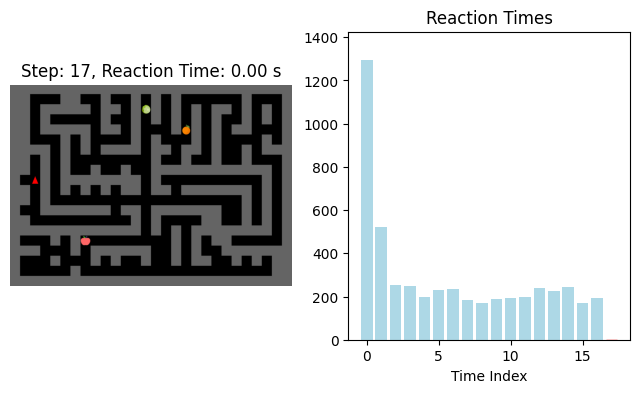

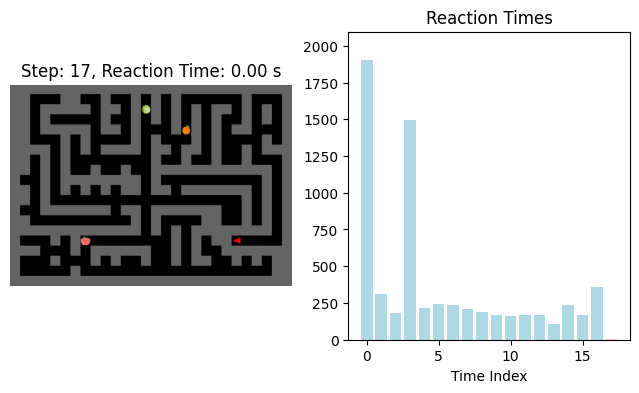

In [15]:
# users_unreliable = [
#     724250996,
#     560893899,
#     1364102698
# ]
# user = users_unreliable[-1]
# # user = 560893899
# # new = df.filter(user=user, eval=False)
# # housemaze_utils.create_episode_reaction_times_video(new.episodes[0])

new = df.filter(eval=True)
housemaze_utils.create_episode_reaction_times_video(new.episodes[0])
housemaze_utils.create_episode_reaction_times_video(new.episodes[1])

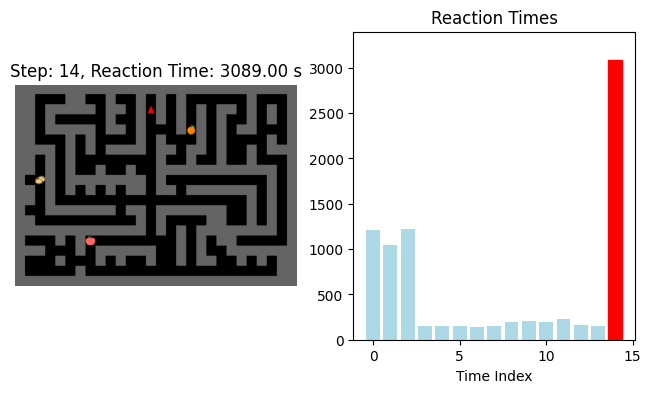

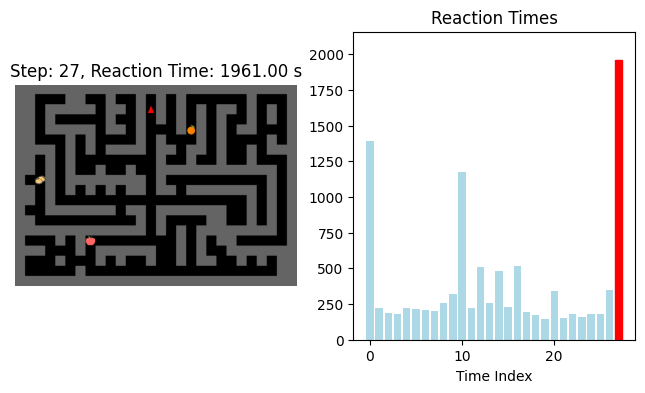

In [16]:
new = df.filter(eval=False)
housemaze_utils.create_episode_reaction_times_video(new.episodes[0])
housemaze_utils.create_episode_reaction_times_video(new.episodes[1])

In [12]:
df.filter(user=user, eval=True).head()

index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,new_path,old_path,user,exp,debug,version,tell_reuse,timer,reversal
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,bool,bool,i64,i64,i64,i64,i64,i64,str
0,"""big_m4_maze_short_eval_diff""",2,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,51,1,true,13,0,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""F,F"""
1,"""big_m4_maze_short_eval_same_bl…",1,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,67,1,true,13,1,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""T,F"""
2,"""big_m4_maze_short_eval_same_bl…",1,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,96,1,true,46,1,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""T,T"""
3,"""big_m4_maze_short_eval_diff""",2,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,97,1,true,29,0,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""T,T"""
4,"""big_m4_maze_long_eval_same_bli…",1,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,149,1,true,29,0,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""F,F"""


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 47 data points
Filtered 52 data points
Filtered 54 data points
Filtered 60 data points
Filtered 52 data points
Filtered 46 data points
Filtered 41 data points
Filtered 66 data points
Filtered 46 data points
Filtered 46 data points
Filtered 47 data points
Filtered 47 data points
Filtered 60 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 46 data points
Filtered 135 data points
Filtered 89 data points
Filtered 56 data points
Filtered 47 data points
Filtered 47 data points
Filtered 53 data points
Filtered 62 data points
Filtered 57 data points
Filtered 23 data points
Filtered 55 data points
Filtered 53 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 32 data p